In [1]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../laptop_data_cleaned.csv")
df.head(5)

,Company,TypeName,Ram,Weight,Price,TouchScreen,Ips,Ppi,Cpu_brand,HDD,SSD,Gpu_brand,Os
0,Apple,Ultrabook,8,1.37,11.175755,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8,1.34,10.776777,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8,1.86,10.329931,0,0,141.211998,Intel Core i5,0,256,Intel,Others
3,Apple,Ultrabook,16,1.83,11.814476,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8,1.37,11.473101,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


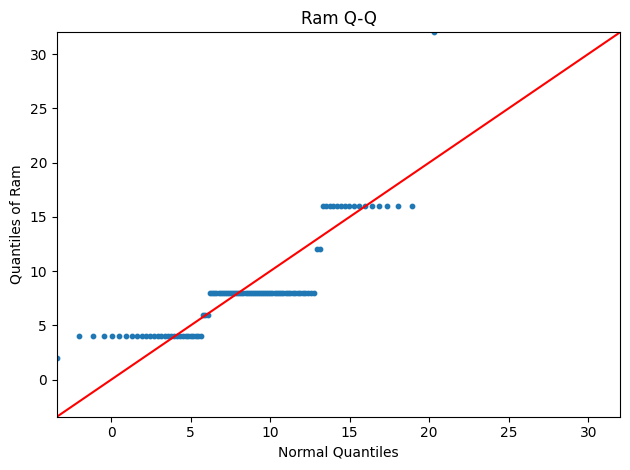

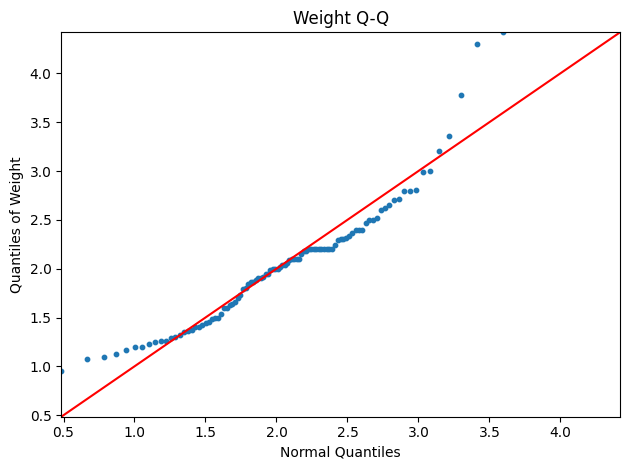

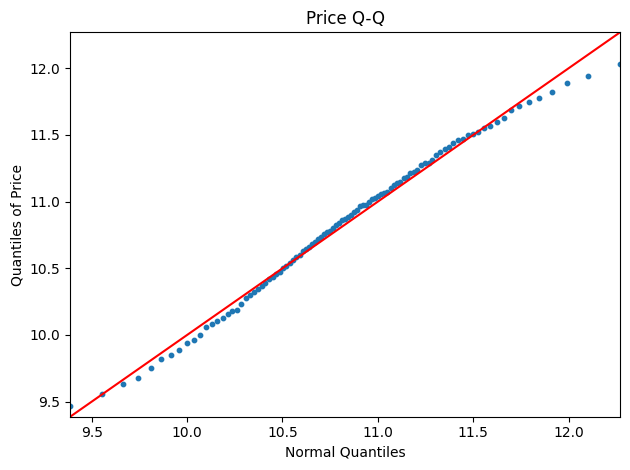

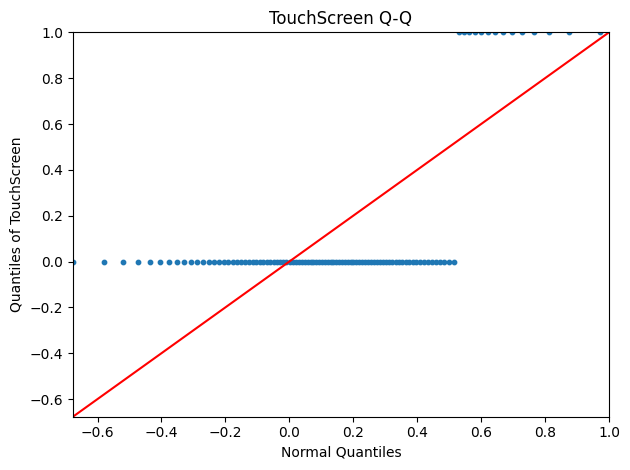

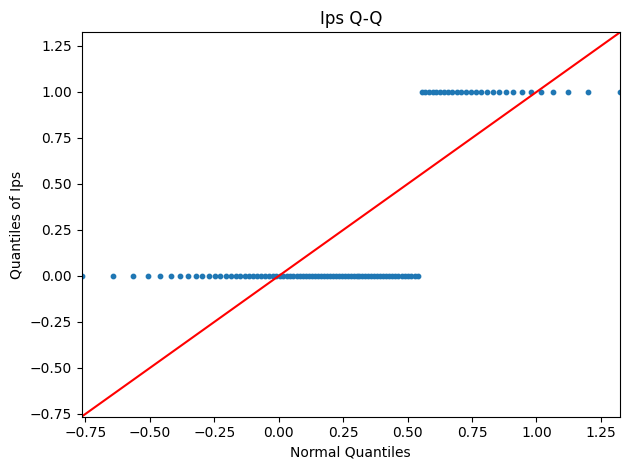

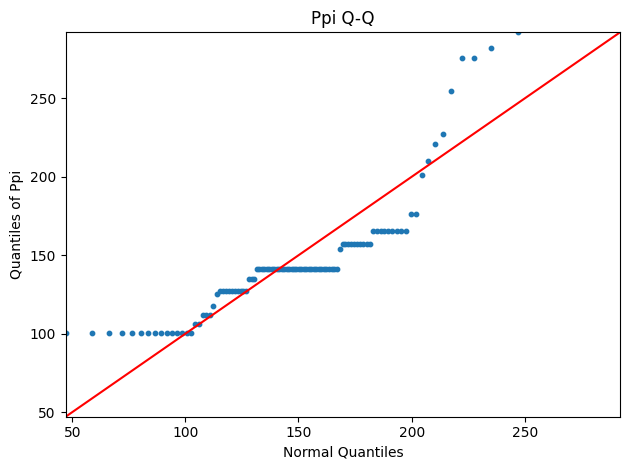

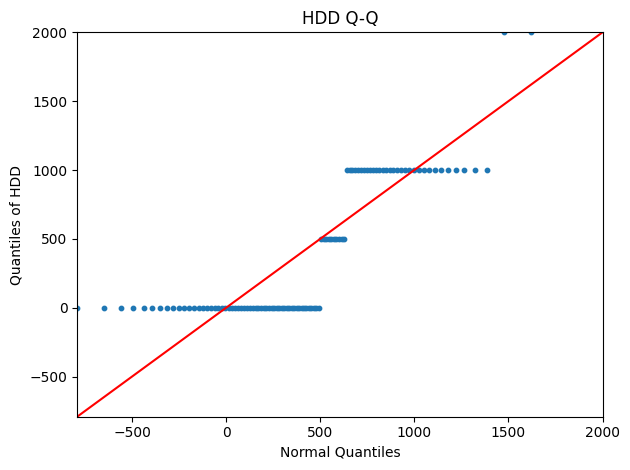

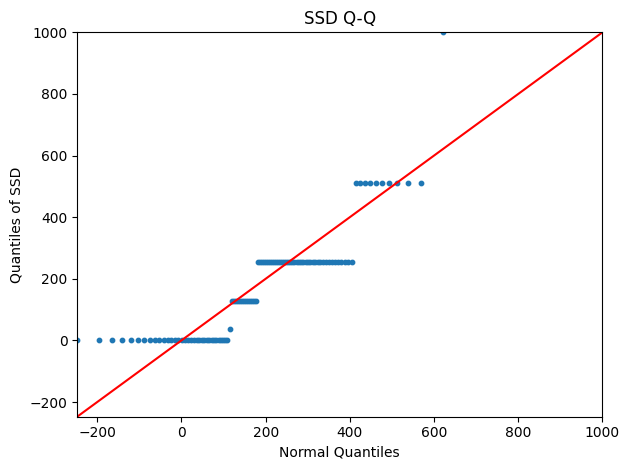

In [2]:
# This snippet displays the Q-Q plots for each numeric column!

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

for column in df.columns:

    # Get rid of any non-numerical columns.
    if pd.api.types.is_numeric_dtype(df[column]):

        # Drop missing values in case it causes problems
        values = df[column].dropna()

        # Fit a normal distribution to THIS column's own scale.
        mean, std = values.mean(), values.std()

        # Make 99 percentiles, evenly spaced.
        probs = np.linspace(0.01, 0.99, 99)

        # Copies dataprep's method. take the sample of the quantiles.
        sample_qntls = values.quantile(probs)

        # Theoretical quantiles: what a perfectly normal distribution with
        # the datas mean and std would look like at each %
        theory_qntls = norm.ppf(probs, mean, std)

        # Combine both sets to find a shared min/max.
        vals = np.concatenate([sample_qntls, theory_qntls])
        lo, hi = vals.min(), vals.max()
        fig, ax = plt.subplots()

        # Plot sample quantiles with theoretical quantiles.
        ax.scatter(theory_qntls, sample_qntls, s=10)

        # Draw a diagonal line.
        ax.plot([lo, hi], [lo, hi], color="r")

        # Force both axes to the same range. Makes the 45 degrees fixed.
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(f"{column} Q-Q")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel(f"Quantiles of {column}")

        plt.tight_layout()
        plt.show()